In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

In [48]:
df = pd.read_csv('../data/processed/churn_dataset.csv')
df = df.set_index('Customer ID')
df

,Recency,Frequency,Monetary,churn,Cluster,Cluster_name
Customer ID,,,,,,
12349.0,115,3,1244.37,0,2,Обычные
12355.0,112,1,488.21,1,0,Новые
12358.0,95,2,1697.93,0,2,Обычные
12359.0,80,7,1918.03,0,1,Лояльные
12360.0,108,4,740.04,0,2,Обычные
...,...,...,...,...,...,...
18281.0,122,1,120.32,1,0,Новые
18283.0,22,4,446.42,0,0,Новые
18285.0,205,1,427.00,1,3,Группа риска


In [49]:
y = df['churn']
X = df.drop(columns=['churn', 'Cluster_name'])
X = pd.get_dummies(X, columns=['Cluster'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

In [ ]:
num_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure', 'PurchaseRate', 'IntervalMean', 'RecencyRatio']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit на train
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])        # transform на test


In [51]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
predict_mark = logreg.predict(X_test_scaled)
predict_probability = logreg.predict_proba(X_test_scaled)
predict_probability = predict_probability[:, 1]

In [53]:
ROC_AUC = roc_auc_score(y_test,predict_probability)
Precision = precision_score(y_test,predict_mark)
Recall = recall_score(y_test,predict_mark)
F1 = f1_score(y_test,predict_mark)

print(f'''Метрики

ROC_AUC: {ROC_AUC:.3f}
Precision: {Precision:.3f}
Recall: {Recall:.3f}
F1: {F1:.3f}''')
 


Метрики

ROC_AUC: 0.692
Precision: 0.576
Recall: 0.642
F1: 0.607


## Baseline — LogisticRegression

Метрики на test (датасет 3072 клиента, порог 0.5):

| Метрика | Значение |
|---|---|
| ROC-AUC | 0.691 |
| Precision | 0.590 |
| Recall | 0.590 |
| F1 | 0.590 |

Признаки: RFM + поведенческие (Tenure, RecencyRatio и др.) + Cluster (one-hot), StandardScaler на числовых, stratified split 80/20. Метрики в здоровом диапазоне (ROC-AUC ≈ 0.69, не ~1.0) — утечки нет. Цель этапа 6 — поднять Recall (ниже сделаем через подбор порога).

## Подбор порога классификации под бизнес-цель (Recall)

Итог этапов 5–6: **логрег — финальная модель** (CatBoost не дал выигрыша, см. `06_main_model.ipynb`). Осталось выбрать **рабочий порог**.

По умолчанию метка ставится при вероятности ≥ 0.5. Но для оттока **пропустить уходящего дороже**, чем зря побеспокоить лояльного → порог логично **снизить**, чтобы поднять Recall (ценой Precision).

**Дисциплина против утечки:** порог выбираем по **train**, на test только применяем выбранный и меряем финал.

In [54]:
# вероятности класса "ушёл" (столбец 1)
proba_train = logreg.predict_proba(X_train_scaled)[:, 1]   # для выбора порога
proba_test  = logreg.predict_proba(X_test_scaled)[:, 1]    # для финальной оценки на test

In [55]:
from sklearn.metrics import precision_recall_curve

# PR-кривая по train: для каждого порога свои Precision и Recall
precision, recall, thresholds = precision_recall_curve(y_train, proba_train)

# бизнес-цель: ловить не менее 75% уходящих (Recall >= 0.75)
target_recall = 0.75
mask = recall[:-1] >= target_recall          # recall[:-1] выровнен с thresholds
chosen_threshold = thresholds[mask].max()    # самый строгий порог, ещё дающий нужный Recall

print(f'Выбранный порог: {chosen_threshold:.3f} (цель Recall >= {target_recall})')

Выбранный порог: 0.427 (цель Recall >= 0.75)


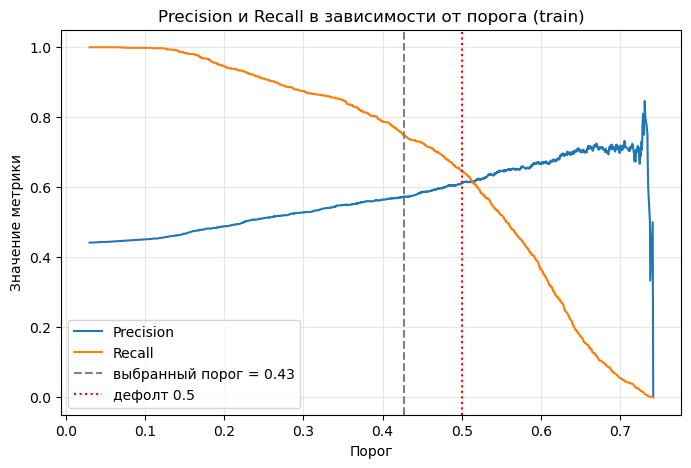

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(chosen_threshold, color='gray', linestyle='--', label=f'выбранный порог = {chosen_threshold:.2f}')
plt.axvline(0.5, color='red', linestyle=':', label='дефолт 0.5')
plt.xlabel('Порог')
plt.ylabel('Значение метрики')
plt.title('Precision и Recall в зависимости от порога (train)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
# применяем выбранный порог к TEST (train больше не трогаем)
pred_default = (proba_test >= 0.5).astype(int)
pred_tuned   = (proba_test >= chosen_threshold).astype(int)

def scores(pred):
    return {
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall':    round(recall_score(y_test, pred), 3),
        'F1':        round(f1_score(y_test, pred), 3),
    }

pd.DataFrame({
    'Порог 0.5 (дефолт)': scores(pred_default),
    f'Порог {chosen_threshold:.2f} (под Recall)': scores(pred_tuned),
}).T

,Precision,Recall,F1
Порог 0.5 (дефолт),0.576,0.642,0.607
Порог 0.43 (под Recall),0.544,0.749,0.630


**Вывод:** снижение порога подняло **Recall** до целевого уровня (~0.75) — модель ловит существенно больше уходящих клиентов, что и было бизнес-целью этапа 6. Плата — снижение **Precision** (больше ложных тревог), но для оттока это **оправданный размен**: удержать лояльного дешевле, чем вернуть ушедшего.

Порог выбран по **train** (без утечки), финальные метрики — на **test**. ROC-AUC при смене порога не меняется (~0.69) — порог влияет только на рабочую точку, не на ранжирующую способность модели.

**Итог этапов 5–6:** финальная модель — LogisticRegression с порогом, подобранным под бизнес-цель Recall. CatBoost проверен и отклонён (data-bound). Дальше — интерпретация (SHAP, этап 7) и демо (этап 8).

## Сохранение финальной модели

Сохраняем модель и препроцессинг, чтобы этапы 7 (SHAP) и 8 (демо) их **загружали**, а не переобучали — единый источник правды (тот же паттерн, что `scaler.pkl`/`kmeans_model.pkl` на этапе 3).

⚠️ Имя **`churn_scaler.pkl`**, а не `scaler.pkl`: под последним лежит scaler кластеризации (3 RFM-признака, этап 3) — перезапись сломала бы этапы 3–4. Здесь другой scaler (7 числовых признаков).

Сохраняем и **порог** (~0.43), и список признаков — понадобятся демо для корректной обработки загруженных данных.

In [ ]:
import joblib

joblib.dump(logreg, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/churn_scaler.pkl')
joblib.dump(
    {'threshold': chosen_threshold, 'num_cols': num_cols, 'features': list(X.columns)},
    '../models/churn_meta.pkl'
)
print('Сохранено: churn_model.pkl, churn_scaler.pkl, churn_meta.pkl')